In [115]:
import sys
sys.path.append('../code')

import glob
import os
import jax
from jax import config
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from jax import jit, vmap
import joblib

import jaxley as jx
import jaxley.optimize.transforms as jt
from jaxley.connect import fully_connect, connect, sparse_connect, connectivity_matrix_connect
import optax
import pickle

import torch
from torch import optim
from sbi import utils as utils
from tqdm import tqdm

from network_utils import (make_network, set_train_parameters, get_currents_nocontext, log_scale_forward, linear_scale_forward,
                           get_prior_dict, initialize_params, get_parameter_names)
from flow_utils import UniformPrior, PriorFiltered
from sklearn.linear_model import LinearRegression, Ridge

from neurodsp.spectral import compute_spectrum

import prior_configurations as prior_config
save_path = '/users/ntolley/data/ntolley/dendractor/memory_permutations'

config_list = [
    ('cuesomanmda_Esomaampa_Edendampa', prior_config.update_prior_dict_cuesomanmda_Esomaampa_Edendampa), # 4
    ('cuesomaampa_Esomaampa_Edendampa', prior_config.update_prior_dict_cuesomaampa_Esomaampa_Edendampa), # 5
    ('cuedendnmda_Esomaampa_Edendampa', prior_config.update_prior_dict_cuedendnmda_Esomaampa_Edendampa), # 10
    ('cuedendampa_Esomaampa_Edendampa', prior_config.update_prior_dict_cuedendampa_Esomaampa_Edendampa), # 11
    ]


def simulate_sweep(theta, params, cue_currents, seed):
    seed_key = jax.random.split(jax.random.PRNGKey(seed), num=4)
    rng = np.random.default_rng(seed=123)

    key_order, conn_names, biophysics_names = get_parameter_names()

    # params is a list of single element dicitonaries, this is to just find the index
    key_mapping = {list(param_dict.keys())[0]: idx for idx, param_dict in enumerate(params)}
    theta_dict = {param_name: prior_dict[param_name]['rescale_function'](
        theta[param_idx], prior_dict[param_name]['bounds']) for 
        param_idx, param_name in enumerate(key_order)}

    # Need to treat connections with special care
    # First create vector with identicial conductances for every synapse
    # Then mask out connections based on their probability
    for conn_name in conn_names:
        conn_g_name = f'{conn_name}_gS'
        conn_prob_name = f'{conn_name}_pconn'
        key_idx = key_mapping[conn_g_name]
        num_vals = len(params[key_idx][conn_g_name])

        new_vals = np.repeat(theta_dict[conn_g_name], num_vals)
        mask = rng.uniform(0, 1, size=num_vals) < theta_dict[conn_prob_name]
        new_vals = new_vals * mask

        params[key_idx][conn_g_name] = new_vals

    # No prob masking for biophysics, just update param vectors
    for param_name in biophysics_names:
        key_idx = key_mapping[param_name]
        num_vals = len(params[key_idx][param_name])

        new_vals = np.repeat(theta_dict[param_name], num_vals)
        params[key_idx][param_name] = new_vals


    net.delete_stimuli()
    
    noise_scale = 0.06


    # Attach stimulation
    data_stimuli = None
    data_stimuli = net.cell(list(gid_ranges['cue'])).branch(0).comp(0).data_stimulate(cue_currents, data_stimuli=data_stimuli)


    net.delete_recordings()
    net.cell(list(gid_ranges['E'])).branch([0,1,2,3]).comp([0,1,2,3]).record('v')

    s = jx.integrate(net, t_max=t_max, params=params, data_stimuli=data_stimuli, delta_t=dt)
    return s

def get_opt_data(data_path):
    print(f'Loading data from: {data_path}')
    theta_list = list()
    error_list = list()

    num_flows = 10
    for flow_idx in range(num_flows):
        print(f'Flow {flow_idx}')
        theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
        error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')


        rate_gids = list(gid_ranges['E_rate']) + list(gid_ranges['I_rate'])
        voltage_gids = list(gid_ranges['E'])

        theta_list.append(theta)
        error_list.append(error)


    error_sort = np.argsort(error)

    res_dict = {'theta_list': theta_list, 'error_list': error_list, 'error_sort': error_sort, 
                }

    return res_dict




In [116]:
def update_prior_dict_nointrinsic_connections(prior_dict):
    g_off = (-100, -100)
    p_off = (0, 0)

    # Cue
    # prior_dict['cue_Esoma_ampa_gS']['bounds'] = g_off
    # prior_dict['cue_Esoma_ampa_pconn']['bounds'] = p_off

    # prior_dict['cue_Esoma_nmda_gS']['bounds'] = g_off
    # prior_dict['cue_Esoma_nmda_pconn']['bounds'] = p_off

    # prior_dict['cue_Edend_ampa_gS']['bounds'] = g_off
    # prior_dict['cue_Edend_ampa_pconn']['bounds'] = p_off

    # prior_dict['cue_Edend_nmda_gS']['bounds'] = g_off
    # prior_dict['cue_Edend_nmda_pconn']['bounds'] = p_off

    # EEsoma
    prior_dict['EE_ampa_gS']['bounds'] = g_off
    prior_dict['EE_ampa_pconn']['bounds'] = p_off
    prior_dict['EE_nmda_gS']['bounds'] = g_off
    prior_dict['EE_nmda_pconn']['bounds'] = p_off

    # EEdend
    prior_dict['EE_dend_ampa_gS']['bounds'] = g_off
    prior_dict['EE_dend_ampa_pconn']['bounds'] = p_off
    prior_dict['EE_dend_nmda_gS']['bounds'] = g_off
    prior_dict['EE_dend_nmda_pconn']['bounds'] = p_off

    # IEsoma
    prior_dict['IE_gaba_gS']['bounds'] = g_off
    prior_dict['IE_gaba_pconn']['bounds'] =  p_off

    # IEdend
    prior_dict['IE_dend_gaba_gS']['bounds'] = g_off
    prior_dict['IE_dend_gaba_pconn']['bounds'] = p_off

    # II
    prior_dict['II_gaba_gS']['bounds'] = g_off
    prior_dict['II_gaba_pconn']['bounds'] =  p_off

    # EI
    prior_dict['EI_ampa_gS']['bounds'] = g_off
    prior_dict['EI_ampa_pconn']['bounds'] =  p_off


dt = 0.025
t_max = 500
time_vec = jnp.arange(0, t_max, dt)

downsample_factor = 10

for config_name, update_prior_dict in config_list:
    data_path = f'{save_path}/{config_name}'

    with open(f'{data_path}/jaxley_net.pkl', 'rb') as f:
        net, gid_ranges = pickle.load(f)

    res_dict = get_opt_data(data_path)

    # # Choose best from all sims
    theta = np.concatenate(res_dict['theta_list'], axis=0)
    error = np.concatenate(res_dict['error_list'])
    theta_sort = np.argsort(error)
    theta_idx = theta_sort[0]

    # Choose theta with error closest to target error
    # target_error = 0.25
    # theta = np.concatenate(res_dict['theta_list'], axis=0)
    # error = np.concatenate(res_dict['error_list'])
    # theta_idx = np.argmin(np.abs(error - target_error))

    # # Choose best from last run
    # theta = res_dict['theta_list'][-1]
    # error = res_dict['error_list'][-1]
    # theta_sort = np.argsort(error)
    # theta_idx = theta_sort[0]

    print(f"Starting error: {error[theta_idx]}")

    num_E_cells, num_I_cells = len(gid_ranges['E']), len(gid_ranges['I'])
    num_cue_cells = len(gid_ranges['cue'])

    params, _ = set_train_parameters(net, gid_ranges)
    prior_dict = get_prior_dict()
    update_prior_dict(prior_dict)
    update_prior_dict_nointrinsic_connections(prior_dict)

    input_list = jnp.array([[-2,-2], [2,2], [-2, 2], [2,-2]])

    num_cond = input_list.shape[0]
    input_data = [get_currents_nocontext(input_list[idx], gid_ranges, t_max, dt) for idx in range(num_cond)]
    cue_currents = jnp.stack([input_data[idx][0] for idx in range(num_cond)])
    targets = np.concatenate([input_data[idx][1][:2, ::downsample_factor] for idx in range(num_cond)], axis=1).T
    targets_stacked = jnp.stack([input_data[idx][1][:2, ::downsample_factor] for idx in range(num_cond)])

    batch_size = 1
    cue_currents_batch = jnp.tile(cue_currents, (batch_size, 1, 1))
    print(cue_currents_batch.shape)

    jitted_simulate = jit(simulate_sweep)
    jitted_vmapped_simulate = vmap(jitted_simulate, in_axes=(0, None, 0, 0))

    best_theta = theta[theta_idx:theta_idx+1, :]
    
    # Run simulations in batch
    num_random_init = 1
    seed_array = jnp.arange(0, num_cond*num_random_init)

    output_list = list()
    for start_idx in range(0, num_random_init, batch_size):
        print(f'Batch: {start_idx}')
        end_idx = np.min([start_idx + batch_size, num_random_init])

        theta_batch = jnp.repeat(best_theta, num_cond * (end_idx - start_idx), axis=0)
        seed_batch = seed_array[start_idx*num_cond:end_idx*num_cond]

        output = np.array(jitted_vmapped_simulate(theta_batch, params, cue_currents_batch, seed_batch))
        output = output[:, :, ::downsample_factor]
        output_list.append(output)
    output_array = np.concatenate(output_list)

    res_dict = {
        'name': config_name,
        'output_array': output_array,
        'targets': targets,
        'targets_stacked': targets_stacked,
        'input_list': input_list,
        'theta': theta,
        'gid_ranges': gid_ranges
    }

    cellsim_save_path = f'{save_path}/cell_ephys_sim/'

    # Set up folder paths
    os.makedirs(cellsim_save_path, exist_ok=True)

    fname = f'{config_name}_cell_ephys_sim.pkl'
    with open(f'{cellsim_save_path}/{fname}', 'wb') as f:
        pickle.dump(res_dict,f)

Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations/cuesomanmda_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9
Starting error: 0.38327252393830635
Number of newly added trainable parameters: 97. Total number of trainable parameters: 97
Number of newly added trainable parameters: 48. Total number of trainable parameters: 145
Number of newly added trainable parameters: 97. Total number of trainable parameters: 242
Number of newly added trainable parameters: 194. Total number of trainable parameters: 436
Number of newly added trainable parameters: 194. Total number of trainable parameters: 630
Number of newly added trainable parameters: 194. Total number of trainable parameters: 824
Number of newly added trainable parameters: 194. Total number of trainable parameters: 1018
Number of newly added trainable parameters: 97. Total number of trainable parameters: 1115
Number of newly added trainable parameters: 64. Total numbe

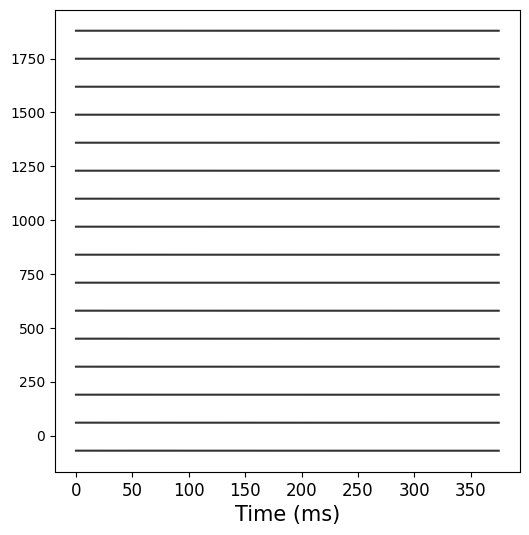

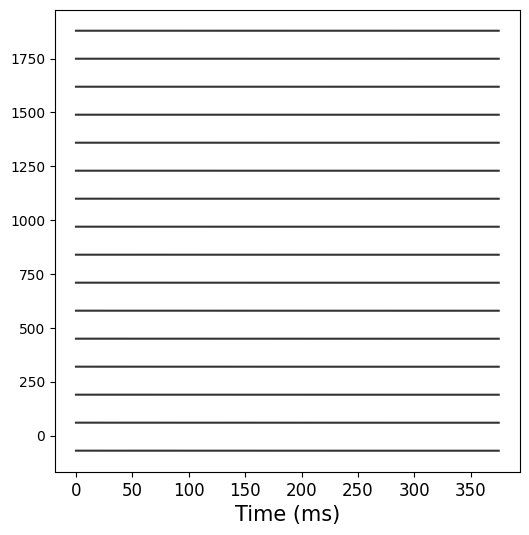

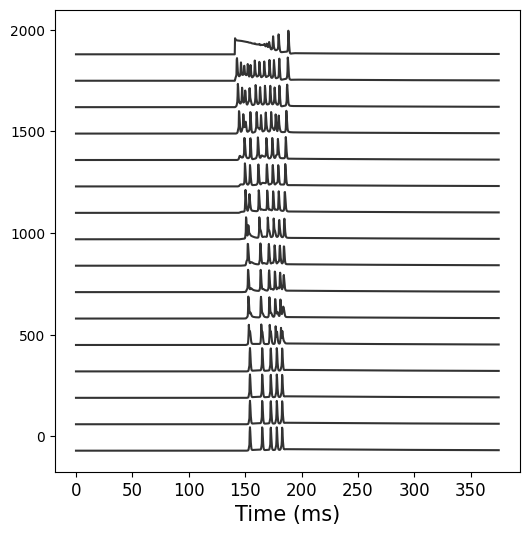

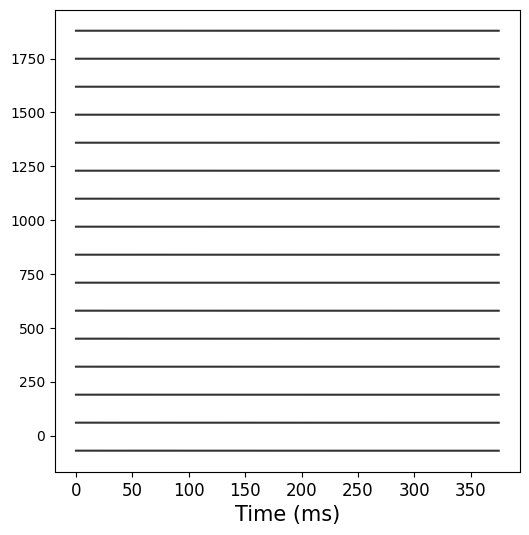

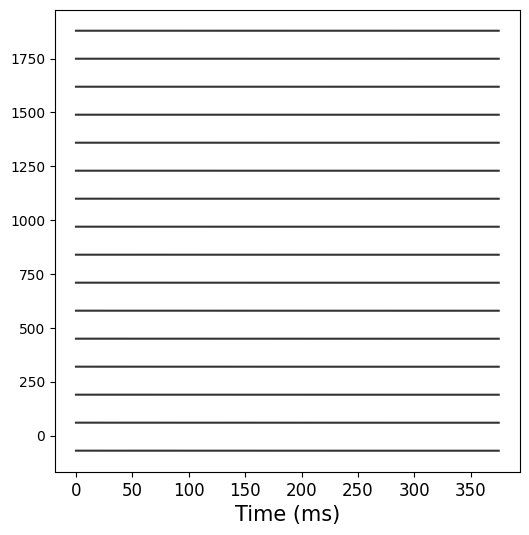

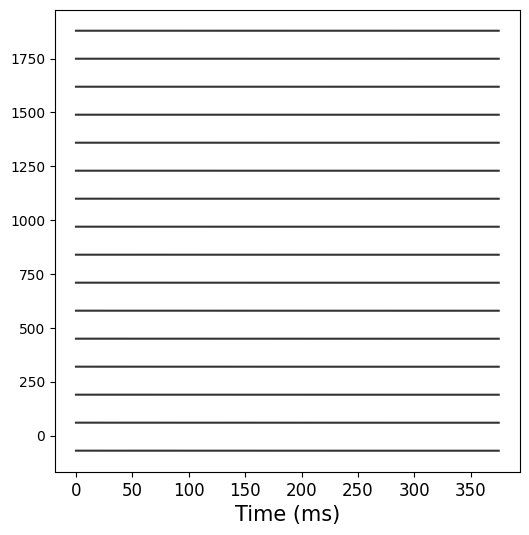

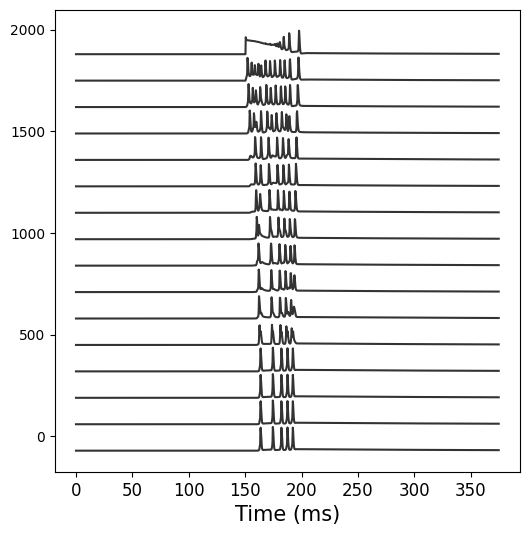

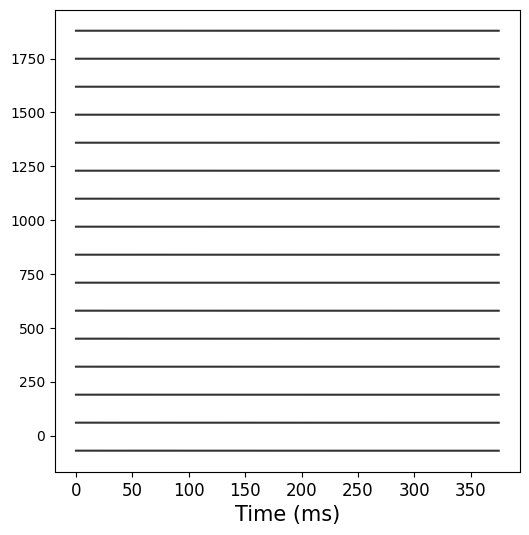

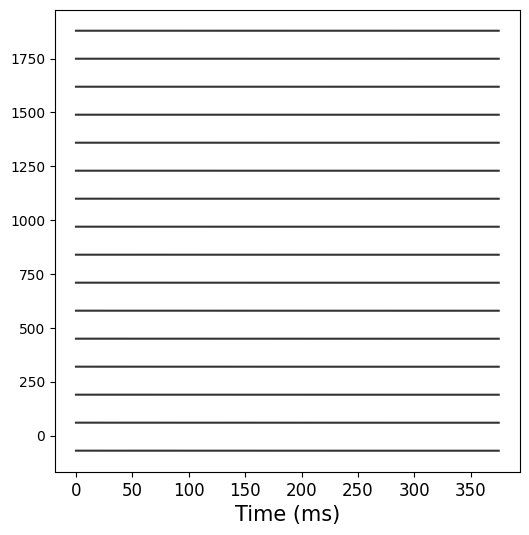

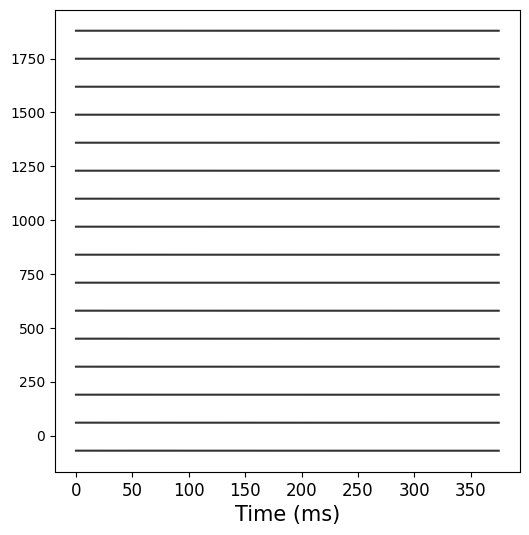

In [114]:
ticksize = 12
labelsize = 15
voltage_spacing = 130

# neuron_idx = 11
for neuron_idx in range(20,30):
    num_comps = 16
    comp_start_idx = neuron_idx * num_comps
    comp_end_idx = comp_start_idx + num_comps

    voltages = output_array[0, comp_start_idx:comp_end_idx, :-1]

    sample_start = 500
    sample_stop = 2000

    # sample_start = 1100
    # sample_stop = 1300

    plt.figure(figsize=(6,6))
    _ = plt.plot(time_vec[::downsample_factor][:(sample_stop-sample_start)], voltages[:, sample_start:sample_stop].T + np.arange(num_comps) * voltage_spacing, color='k', alpha=0.8)
    plt.xlabel('Time (ms)', fontsize=labelsize)
    plt.xticks(fontsize=ticksize)


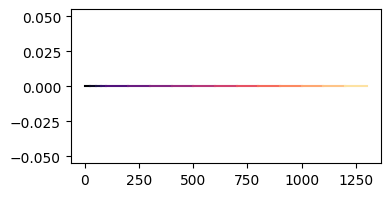

In [110]:
net.compute_xyz()
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

import matplotlib as mpl
cmap = mpl.colormaps['magma']

comp_count = 0
for idx1 in range(4):
    for idx2 in range(4):
        net.cell([list(gid_ranges['E'])[0]]).branch([idx1]).comp([idx2]).vis(ax=ax, color=cmap(comp_count / 16))

        comp_count += 1
